In [1]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import powerlaw

plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['figure.dpi'] = 150
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['ytick.minor.size'] = 3
plt.rcParams['axes.titlepad'] = 10


In [ ]:
# path = '/work/lpsha/data/regime/' # old
path = '/home/lpsha/s154446/fractality/data/city_degrees/t10_a20/'
cities = os.listdir(path)

real_degree_sequence = np.array([])
for city in tqdm(cities):
        real_degree_sequence=np.append(real_degree_sequence, np.loadtxt(path+city))

100%|███████████████████████████████████████████| 78/78 [00:01<00:00, 60.12it/s]


100%|███████████████████████████████████████████| 78/78 [00:00<00:00, 97.80it/s]


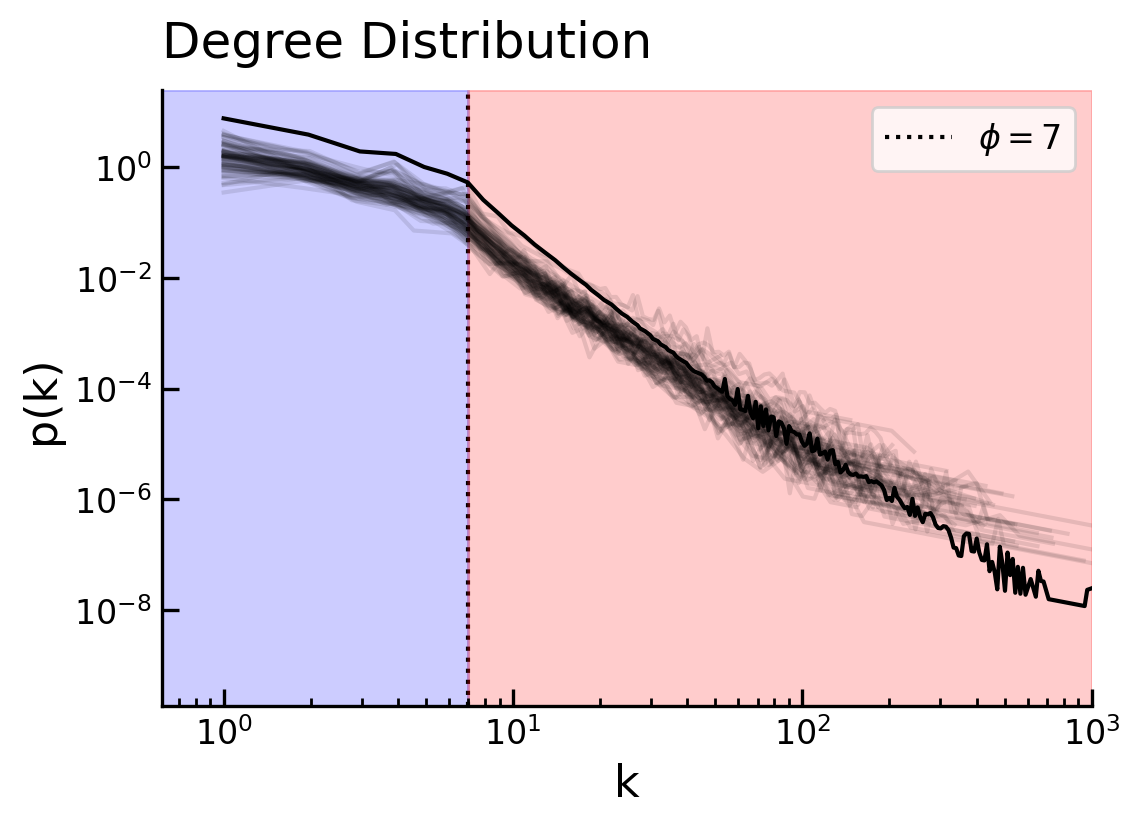

In [4]:
path = '/home/lpsha/s154446/fractality/data/city_degrees/t10_a20/'

full = np.array([])
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4),dpi=200)

cities = os.listdir(path)

for city in tqdm(cities):

    d=np.loadtxt(path+city)
    full=np.append(full, d)

    y, x = np.histogram(d, bins=np.logspace(0, np.log10(d.max()), len(np.unique(d))), density=True)
    x = x[:-1]
    x_nn = x[y != 0][:-1]
    y_nn = y[y != 0][:-1]
    ax.plot(x_nn, y_nn, alpha=0.1, zorder=2, color='k')

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_title("Degree Distribution", loc='left', pad=12)
ax.set_xlabel("k")
ax.set_ylabel("p(k)")

y, x = np.histogram(full, bins=np.logspace(0, np.log10(full.max()), len(np.unique(full))), density=True)
x = x[:-1]
x_nn = x[y != 0][:-1]
y_nn = y[y != 0][:-1]
ax.plot(x_nn, y_nn, alpha=1, zorder=2, color='k')

ax.yaxis.set_minor_formatter(plt.NullFormatter())

# Hide top/right spines (Nature style)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Only bottom/left axes
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

# Major ticks (not too many)
ax.xaxis.set_major_locator(plt.LogLocator(base=10.0))
ax.yaxis.set_major_locator(plt.LogLocator(base=10.0))

# Minor ticks
ax.xaxis.set_minor_locator(plt.LogLocator(base=10.0, subs=np.arange(1, 10)))
ax.yaxis.set_minor_locator(plt.LogLocator(base=10.0, subs=np.arange(1, 10)))

# Appearance
ax.tick_params(which='major', length=6, width=1.2)
ax.tick_params(which='minor', length=3, width=1.0)

# Shade area from "x = 0" (small positive) up to x = 7
ax.axvspan(xmin=0, xmax=6.99, color='blue', alpha=0.2, zorder=-1)
ax.axvline(7, color='k', linestyle='dotted', label=r'$\phi = $' + str(7),zorder=-1)
ax.axvspan(xmin=7.01, xmax=1000, color='red', alpha=0.2, zorder=-1)

plt.legend()
ax.set_xlim(right=1000)
plt.show()

In [5]:
def compute_ks(degree,min_range):
    distance = []
    ass = []
    for i_min in min_range:
        fit = powerlaw.Fit(degree,discrete=True,xmin=i_min)
        a = fit.alpha
        xmin = fit.xmin
        x_fit = degree[degree>xmin]
        
        distance.append(fit.power_law.D)
        ass.append(a) 

    return np.array(distance), min_range, ass

In [6]:
d=real_degree_sequence
d=d[d != 0]
ks_dist, xmins, a = compute_ks(d, range(1,25))

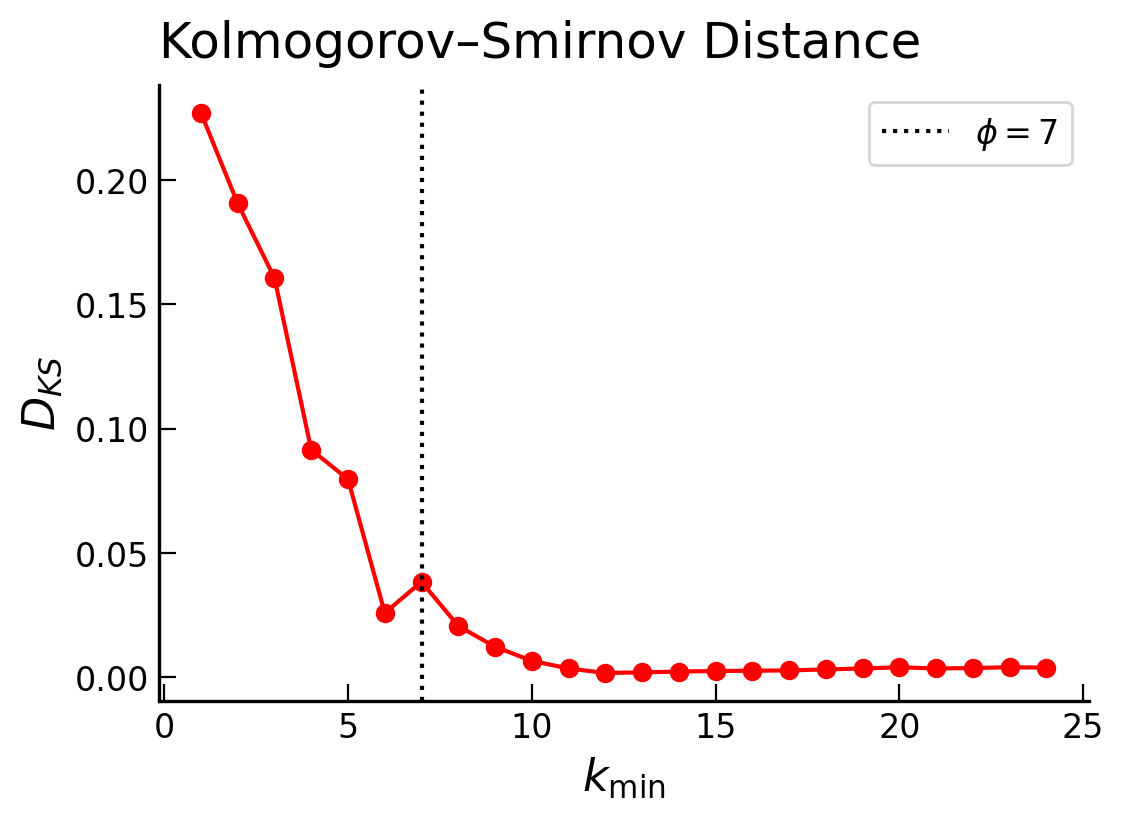

In [7]:
fig, ax2 = plt.subplots(nrows=1,ncols=1,dpi=200,figsize=(6,4))

shift=7

ax2.scatter(xmins,ks_dist,color='red')
ax2.plot(xmins,ks_dist,color='red')


ax2.axvline(shift, color='k', linestyle='dotted', label=r'$\phi = $' + str(shift))
ax2.set_xlabel(r'$k_{\min}$')
ax2.set_ylabel(r'$D_{KS}$')
ax2.set_title('Kolmogorov–Smirnov Distance', loc='left')


# Hide top/right spines (Nature style)
ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Only bottom/left axes
ax2.xaxis.set_ticks_position('bottom')
ax2.yaxis.set_ticks_position('left')

plt.legend()
plt.show()

# V2

In [ ]:
import sys
import os
import sys
sys.path.append('/home/lpsha/s154446/fractality/')
from dgdc import get_dual_dir_con
import numpy as np
from multiprocessing import Pool
import osmnx as ox
import argparse
import os

In [18]:
# def get_degree_seq(city, t_buffer, a_threshold):
#     G = ox.graph.graph_from_place(city)
#     gdf_merged, _, _, _ = get_dual_dir_con(t_buffer=t_buffer, a_threshold=a_threshold, data=G, enforce_degree2=False)
#     degree_sequence = np.array(gdf_merged.degree)
#     return degree_sequence

In [ ]:
G = ox.graph.graph_from_place('Oslo, Norway')
print('Oslo, Norway')

gdf_merged, _, _, _ = get_dual_dir_con(t_buffer=20, a_threshold=10, data=G, enforce_degree2=False)
degree_sequence = np.array(gdf_merged.degree)